Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

Load Dataset

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("cars.csv")
df.head()

Saving cars.csv to cars.csv


,Car_Name,Year,Price
0,Hyundai Creta E,2015,900000
1,Hyundai Creta S,2016,1000000
2,Hyundai Creta SX,2017,1100000
3,Hyundai Creta SX Plus,2018,1200000
4,Hyundai Creta Facelift,2019,1300000


Data Understanding

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
df.info()
df.describe()

Dataset Shape: (8, 3)

Columns: Index(['Car_Name', 'Year', 'Price'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Car_Name  8 non-null      object
 1   Year      8 non-null      int64 
 2   Price     8 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 324.0+ bytes


,Year,Price
count,8.00000,8.000000e+00
mean,2018.50000,1.250000e+06
std,2.44949,2.449490e+05
min,2015.00000,9.000000e+05
25%,2016.75000,1.075000e+06
50%,2018.50000,1.250000e+06
75%,2020.25000,1.425000e+06
max,2022.00000,1.600000e+06


Data Preprocessing

In [ ]:
df.isnull().sum()
X = df[["Year"]]
y = df["Price"]

Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Building
Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

Polynomial Regression

In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
poly_pred = poly_model.predict(X_poly_test)

Ridge Regression

In [ ]:
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

Model Comparsion

In [ ]:
print("Linear Regression:", r2_score(y_test, lr_pred))
print("Polynomial Regression:", r2_score(y_test, poly_pred))
print("Ridge Regression:", r2_score(y_test, ridge_pred))

Linear Regression: 1.0
Polynomial Regression: 1.0
Ridge Regression: 0.9990574040908693


Predict Price for 2022


In [ ]:
pred_2026 = lr.predict(pd.DataFrame([[2026]], columns=["Year"]))
print("Predicted price for Hyundai Creta 2026:", pred_2026[0])

Predicted price for Hyundai Creta 2026: 1999999.9999999702


Visualization

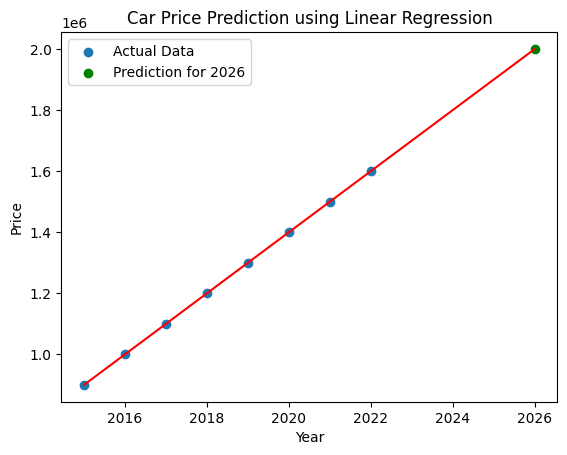

In [ ]:
years = np.arange(df["Year"].min(), 2027).reshape(-1,1)
plt.scatter(X, y, label="Actual Data")
years_df = pd.DataFrame(years, columns=["Year"])
plt.plot(years, lr.predict(years_df), color="red")
plt.scatter(2026, pred_2026, color="green", label="Prediction for 2026")
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Car Price Prediction using Linear Regression")
plt.legend()
plt.show()